Data: n=3,512,919  censored=640,328 (18.2%)
Employers=7,276  SOC=19  States=56  Levels=4
Building design matrix …
  3,512,919 x 77  (2164.0 MB)
Demeaning within employer …
Warm-starting from demeaned OLS …
Optimising (p=77 parameters + concentrated sigma) …
ABNORMAL: 
σ = 0.12678   log-lik = 1413412.99


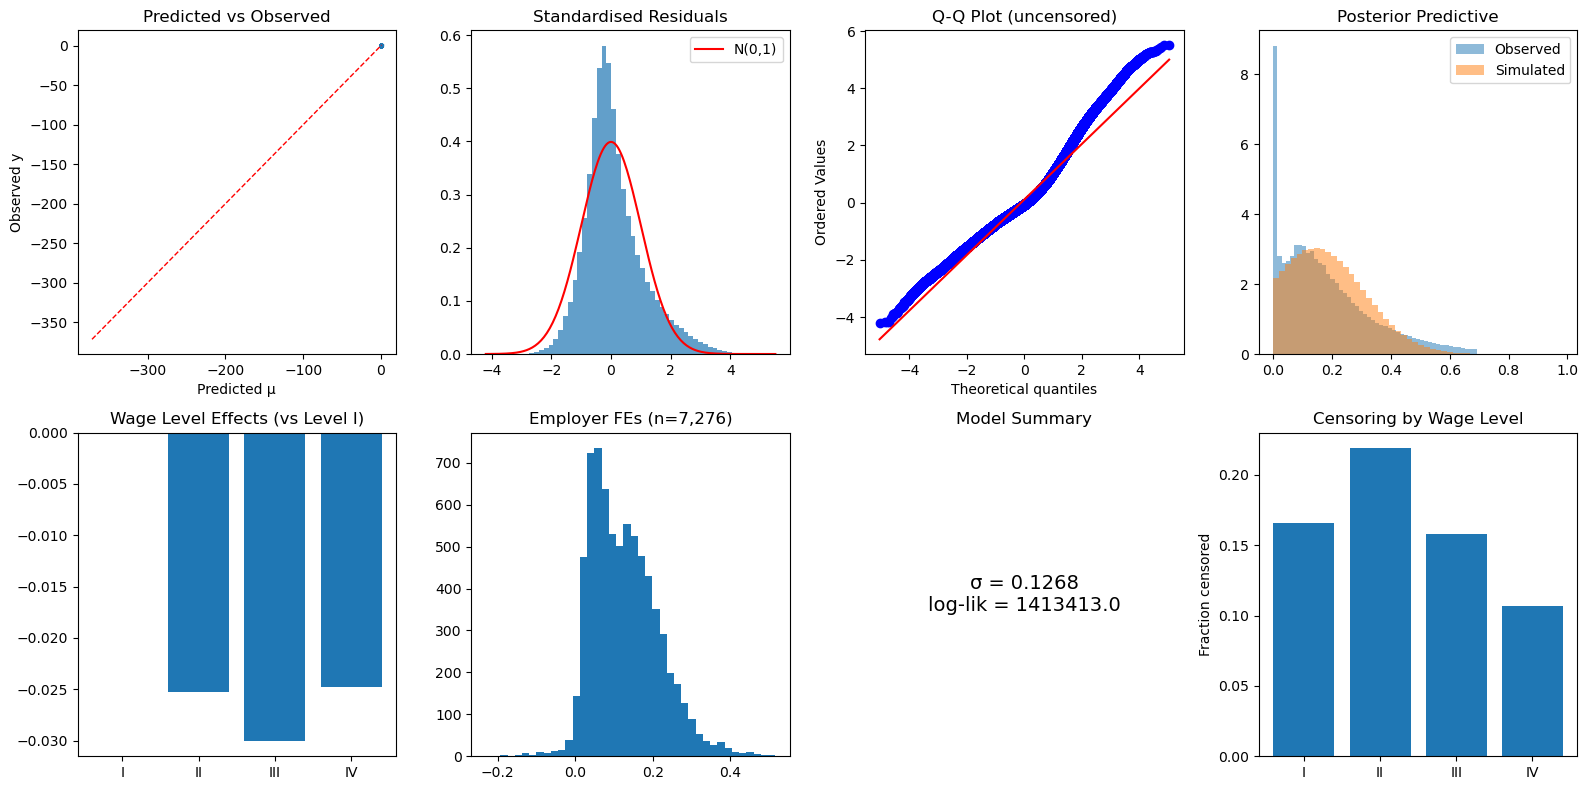

In [1]:
# =========================
# CLASSICAL TOBIT MODEL (MLE) 
# =========================
# Left-censored at 0 on log(wage_ratio).
# Model: y* = beta0 + gamma[L] + delta[S] + eta[ST] + alpha[E] + eps
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from scipy.special import log_ndtr
import warnings
warnings.filterwarnings("ignore")

EPS = 1e-8

# =========================
# DATA PREP 
# =========================

def prepare_data(df):
    df = df.copy()

    df["SOC_2DIGIT"] = df["SOC_CODE"].astype(str).str[:2]
    soc_counts = df["SOC_2DIGIT"].value_counts()
    df["SOC_F"] = df["SOC_2DIGIT"].where(
        df["SOC_2DIGIT"].isin(soc_counts[soc_counts >= 100].index), "OTHER"
    )

    state_counts = df["WORKSITE_STATE"].value_counts()
    df["STATE_F"] = df["WORKSITE_STATE"].where(
        df["WORKSITE_STATE"].isin(state_counts[state_counts >= 100].index), "OTHER"
    )

    level_map = {"I": 0, "II": 1, "III": 2, "IV": 3}
    L_raw = df["WAGE_LEVEL_CLEAN"].astype(str).str.strip().str.upper()
    L = L_raw.map(level_map)

    y_raw = np.log(df["wage_ratio"].values)
    mask = L.notna() & np.isfinite(y_raw)

    df = df.loc[mask].copy()
    L  = L.loc[mask].astype(np.int64).values
    y  = np.maximum(y_raw[mask], 0.0)
    censored = y == 0.0

    S  = pd.Categorical(df["SOC_F"]).codes.astype(np.int64)
    ST = pd.Categorical(df["STATE_F"]).codes.astype(np.int64)
    E  = pd.Categorical(df["EMPLOYER_NAME_CLEAN"]).codes.astype(np.int64)

    print(f"Data: n={len(y):,}  censored={censored.sum():,} ({100*censored.mean():.1f}%)")
    print(f"Employers={E.max()+1:,}  SOC={S.max()+1}  States={ST.max()+1}  Levels=4")

    return {
        "y": y, "censored": censored,
        "L": L, "E": E, "S": S, "ST": ST,
        "K": 4,
        "N_E":  int(E.max()) + 1,
        "N_S":  int(S.max()) + 1,
        "N_ST": int(ST.max()) + 1,
    }

# =========================
# SMALL DESIGN MATRIX  (no employer columns)
# =========================

def build_small_X(data):
    
    n   = len(data["y"])
    K   = data["K"]
    N_S = data["N_S"]
    N_ST= data["N_ST"]

    cols = [np.ones((n, 1))]
    for k in range(1, K):                  # wage-level dummies, drop level 0
        cols.append((data["L"] == k).reshape(-1, 1).astype(float))
    for s in range(1, N_S):               # SOC dummies, drop SOC 0
        cols.append((data["S"] == s).reshape(-1, 1).astype(float))
    for st in range(1, N_ST):             # state dummies, drop state 0
        cols.append((data["ST"] == st).reshape(-1, 1).astype(float))

    return np.hstack(cols)


# =========================
# EMPLOYER PROFILE-OUT  
# optimizing jointing with employer number large takes 
# too much memory; switching to a profile-out strategy
# =========================

def employer_demean(arr, E, N_E):
    """Subtract within-employer mean from arr (1-D or 2-D column-wise)."""
    if arr.ndim == 1:
        means = np.bincount(E, weights=arr, minlength=N_E) / np.maximum(np.bincount(E, minlength=N_E), 1)
        return arr - means[E]
    else:
        out = np.empty_like(arr)
        counts = np.bincount(E, minlength=N_E).astype(float)
        for j in range(arr.shape[1]):
            m = np.bincount(E, weights=arr[:, j], minlength=N_E) / np.maximum(counts, 1)
            out[:, j] = arr[:, j] - m[E]
        return out

def recover_employer_effects(y, X, beta, E, N_E):
    """alpha[e] = mean(y - X@beta) within employer e."""
    resid = y - X @ beta
    counts = np.bincount(E, minlength=N_E).astype(float)
    alpha = np.bincount(E, weights=resid, minlength=N_E) / np.maximum(counts, 1)
    return alpha


# =========================
# LOG-LIKELIHOOD  (Classical tobit, left-censored at 0)
# =========================

def tobit_nll_and_grad(beta, sigma, Xd, yd, obs, cens):
    """
    Returns (neg_log_lik, grad_beta) for fixed sigma.
    obs / cens are boolean index arrays for uncensored / censored rows.
    """
    mu_obs  = Xd[obs]  @ beta
    mu_cens = Xd[cens] @ beta

    r      = (yd[obs] - mu_obs) / sigma          # standardised residuals
    z_cens = -mu_cens / sigma                     # (0 - mu) / sigma

    # log-likelihood
    ll = (-0.5 * (r**2) - 0.5 * np.log(2 * np.pi) - np.log(sigma)).sum() \
       + log_ndtr(z_cens).sum()

    # gradient w.r.t. beta
    phi_over_Phi = np.exp(stats.norm.logpdf(z_cens) - log_ndtr(z_cens))  # numerically stable
    grad = (Xd[obs].T @ r) / sigma \
         + (Xd[cens].T @ phi_over_Phi) / sigma    # censored contribution (negative sign cancels)

    return -ll, -grad


def concentrated_nll(beta, sigma_ref, Xd, yd, obs, cens, n_obs):
    """
    update sigma analytically for current beta.
    """
    # Analytical sigma update (moment condition for uncensored observations):
    #   sigma^2 = mean((y - mu)^2 for uncensored)
    # This is only exact for pure OLS but works well as a quasi-Newton warm update.
    # We iterate once per call — the optimizer handles the outer loop.
    mu_obs = Xd[obs] @ beta
    sigma  = max(np.sqrt(np.mean((yd[obs] - mu_obs) ** 2)), EPS)
    sigma_ref[0] = sigma

    nll, grad = tobit_nll_and_grad(beta, sigma, Xd, yd, obs, cens)
    return nll, grad


# =========================
# FIT MODEL
# =========================

def fit_model(data, verbose=True):
    y, censored = data["y"], data["censored"]
    E, N_E      = data["E"], data["N_E"]
    obs, cens   = ~censored, censored

    print("Building design matrix …")
    X = build_small_X(data)
    n, p = X.shape
    print(f"  {n:,} x {p}  ({X.nbytes/1e6:.1f} MB)")

    print("Demeaning within employer …")
    yd = employer_demean(y,   E, N_E)
    Xd = employer_demean(X,   E, N_E)
    # precompute — used for diagnostics, not inside the loop
    XdtXd = Xd.T @ Xd
    Xdtyd = Xd.T @ yd

    print("Warm-starting from demeaned OLS …")
    beta0, *_ = np.linalg.lstsq(Xd[obs], yd[obs], rcond=None)
    sigma_ref  = [max(np.std(yd[obs] - Xd[obs] @ beta0), EPS)]

    print(f"Optimising (p={p} parameters + concentrated sigma) …")
    result = minimize(
        concentrated_nll,
        beta0,
        args=(sigma_ref, Xd, yd, obs, cens, obs.sum()),
        jac=True,                   # function returns (f, grad) together
        method="L-BFGS-B",
        options={"maxiter": 500, "ftol": 1e-11, "gtol": 1e-7},
    )

    beta_hat  = result.x
    sigma_hat = sigma_ref[0]        # last concentrated value
    ll_hat    = -result.fun

    if not result.success:
        print(f"{result.message}")
    else:
        print(f"Converged in {result.nit} iterations ({result.njev} grad evals)")

    print(f"σ = {sigma_hat:.5f}   log-lik = {ll_hat:.2f}")

    alpha_hat = recover_employer_effects(y, X, beta_hat, E, N_E)
    mu_hat    = X @ beta_hat + alpha_hat[E]

    return dict(beta=beta_hat, alpha=alpha_hat, sigma=sigma_hat,
                mu=mu_hat, log_lik=ll_hat, result=result, data=data, X=X)


# =========================
# DIAGNOSTICS
# =========================

def plot_results(result):
    data, y, mu       = result["data"], result["data"]["y"], result["mu"]
    sigma, censored   = result["sigma"], result["data"]["censored"]

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 4)

    ax = fig.add_subplot(gs[0, 0])
    ax.scatter(mu[~censored], y[~censored], alpha=0.1, s=5)
    lims = [min(mu.min(), 0), max(mu.max(), y.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xlabel("Predicted μ"); ax.set_ylabel("Observed y"); ax.set_title("Predicted vs Observed")

    ax = fig.add_subplot(gs[0, 1])
    resid = (y[~censored] - mu[~censored]) / sigma
    ax.hist(resid, bins=60, density=True, alpha=0.7)
    xr = np.linspace(resid.min(), resid.max(), 200)
    ax.plot(xr, stats.norm.pdf(xr), "r-", lw=1.5, label="N(0,1)")
    ax.set_title("Standardised Residuals"); ax.legend()

    ax = fig.add_subplot(gs[0, 2])
    stats.probplot(resid, plot=ax)
    ax.set_title("Q-Q Plot (uncensored)")

    ax = fig.add_subplot(gs[0, 3])
    y_sim = np.maximum(np.random.normal(mu, sigma), 0.0)
    ax.hist(y[y > 0], bins=50, density=True, alpha=0.5, label="Observed")
    ax.hist(y_sim[y_sim > 0], bins=50, density=True, alpha=0.5, label="Simulated")
    ax.legend(); ax.set_title("Posterior Predictive")

    ax = fig.add_subplot(gs[1, 0])
    level_effects = np.concatenate([[0.0], result["beta"][1:4]])
    ax.bar(["I", "II", "III", "IV"], level_effects)
    ax.set_title("Wage Level Effects (vs Level I)")

    ax = fig.add_subplot(gs[1, 1])
    ax.hist(result["alpha"], bins=40)
    ax.set_title(f"Employer FEs (n={data['N_E']:,})")

    ax = fig.add_subplot(gs[1, 2])
    ax.text(0.5, 0.5,
            f"σ = {result['sigma']:.4f}\nlog-lik = {result['log_lik']:.1f}",
            ha="center", va="center", fontsize=14, transform=ax.transAxes)
    ax.axis("off"); ax.set_title("Model Summary")

    ax = fig.add_subplot(gs[1, 3])
    cens_by_L = [censored[data["L"] == k].mean() for k in range(4)]
    ax.bar(["I", "II", "III", "IV"], cens_by_L)
    ax.set_ylabel("Fraction censored"); ax.set_title("Censoring by Wage Level")

    plt.tight_layout()
    plt.show()


# =========================
# RUN
# =========================

if __name__ == "__main__":
    df = pd.read_parquet("final_filtered.parquet")
    df = df[(df.wage_ratio < 2) & (df.wage_ratio > 0.5)]
    df = df[df["EMPLOYER_NAME_CLEAN"].map(df["EMPLOYER_NAME_CLEAN"].value_counts()) >= 100]

    data   = prepare_data(df)
    result = fit_model(data)
    plot_results(result)